In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames, convert_dict_to_dataframe
import re
big_plt_font() 

def S21(f,f0,Q,Qc,a,t):
    #constant phase offset
    phase1 = np.exp(1j*0)
    #frequency dependent phase
    phase2 = np.exp(-2*np.pi*1j*f*0)
    #ideal resonator
    F = (Q/Qc)/(1+2*1j*Q*(f-f0)/f0)

    #real and imaginary components
    S21_complex = phase1*phase2*F
    S21_re = np.real(S21_complex)
    S21_im = np.imag(S21_complex)

    return np.concatenate((S21_re,S21_im))

def S11(f,f0,Q,Qc,a,t):
    #constant phase offset
    phase1 = np.exp(1j*0)
    #frequency dependent phase
    phase2 = np.exp(-2*np.pi*1j*f*0)
    #ideal resonator
    F = (1 - 2*(Q/Qc)/(1+2*1j*Q*(f-f0)/f0))

    #real and imaginary components
    S21_complex = phase1*phase2*F
    S21_re = np.real(S21_complex)
    S21_im = np.imag(S21_complex)

    return np.concatenate((S21_re,S21_im))

def vec_S21(S21_concat):
    l = int(len(S21_concat)/2)
    r = S21_concat[:l]
    i = S21_concat[l:]
    return [r,i]

def vec_S11(S11_concat):
    l = int(len(S11_concat)/2)
    r = S11_concat[:l]
    i = S11_concat[l:]
    return [r,i]

def mag_S21(re_s21, im_s21):
    return (np.sqrt(re_s21**2+im_s21**2))

def phase_S21(re_s21, im_s21):
    return np.arctan(im_s21/re_s21)

def get_Qi(Q, Qc):
    return 1 / (1/Q - 1/Qc)

def fit_S21(s2p_file, pi = [270e6,500,1000,0,0], C='blue', slabel='', start=185e6, stop=205e6):
  filepath = s2p_file
  df = pd.read_csv(filepath,skiprows=6,names=['S11', 'S21', 'freq'])

  freqs_np = np.array(df.freq)
  ReS21 = np.array(df['S21']).astype(complex).real
  ImS21 = np.array(df['S21']).astype(complex).imag

  magS21 = np.sqrt(ReS21**2+ImS21**2)

  

  max_freq = (freqs_np[np.where(magS21==np.max(magS21))])

  start = 250e6  #max_freq[0]-3e6
  stop= 300e6  #max_freq[0]+3e6


  min_index = np.min(np.where(freqs_np>=start)[0])
  max_index = np.max(np.where(freqs_np<=stop)[0])


  reS21_np = np.array(ReS21)[min_index:max_index]
  imS21_np = np.array(ImS21)[min_index:max_index]
  freqs=freqs_np[min_index:max_index]
  pi[0] = max_freq[0] 
    

  S21_data = np.concatenate((reS21_np,imS21_np))

  params, pcov = curve_fit(S21, freqs, S21_data,p0=pi)

  S21_Concat = S21(freqs,params[0],params[1],params[2],0,0)#,params[3],params[4])
  S21_Vec = vec_S21(S21_Concat)

  #plt.plot(freqs/1e6, mag_S21(S21_Vec[0],S21_Vec[1]),'.',color='r', label=f'Q = {round(params[1],2)}')

  S21_mags = np.sqrt(S21_Vec[0]**2+S21_Vec[1]**2)

  plt.plot(freqs/1e6,S21_mags,color=C, label=slabel+f'Q = {round(params[1],2)}')
  plt.xlabel('frequency (MHZ)')
  plt.ylabel('mag(S21)')
  plt.legend()

  
  return params

def fit_S11(s2p_file, pi = [227e6,200,100,0,0], C='blue', slabel='', start=185e6, stop=205e6):
  filepath = s2p_file
  #df = pd.read_csv(filepath,skiprows=6,names=['S11', 'S21', 'freq'])
  df = pd.read_csv(filepath)

  freqs_np = np.array(df['freq'], dtype=np.float64)
  ReS11 = np.array(df['S11'], dtype=np.complex128).real
  ImS11 = np.array(df['S11'], dtype=np.complex128).imag

  print(np.shape(ReS11))

  magS11 = np.sqrt(ReS11**2+ImS11**2)

  

  max_freq = (freqs_np[np.where(magS11==np.max(magS11))])

  start = 210e6  #max_freq[0]-3e6
  stop= 250e6  #max_freq[0]+3e6


  min_index = np.min(np.where(freqs_np>=start)[0])
  max_index = np.max(np.where(freqs_np<=stop)[0])


  reS11_np = np.array(ReS11)[min_index:max_index]
  imS11_np = np.array(ImS11)[min_index:max_index]
  freqs=freqs_np[min_index:max_index]
  pi[0] = max_freq[0] 
    

  S11_data = np.concatenate((reS11_np,imS11_np))

  params, pcov = curve_fit(S11, freqs, S11_data,p0=pi)

  S11_Concat = S11(freqs,params[0],params[1],params[2],0,0)#,params[3],params[4])
  #S11_Concat = S11(freqs,pi[0],pi[1],pi[2],0,0)#,params[3],params[4])
  S11_Vec = vec_S11(S11_Concat)

  #plt.plot(freqs/1e6, mag_S21(S21_Vec[0],S21_Vec[1]),'.',color='r', label=f'Q = {round(params[1],2)}')

  S11_mags = np.sqrt(S11_Vec[0]**2+S11_Vec[1]**2)

  plt.plot(freqs/1e6,S11_mags,color=C, label=slabel+f'Q = {round(params[1],2)}')
  plt.plot(freqs/1e6, magS11[min_index:max_index])
  plt.xlabel('frequency (MHZ)')
  plt.ylabel('mag(S11)')
  plt.legend()
  return params

def plot_S21_fit(f, complex_data): 
    port1 = circuit.notch_port()
    port1.add_data(f,complex_data)
    port1.autofit()
    fit_results = port1.fitresults4
    naming_map = {'Qi_no_corr': 'Qi', 'absQc': 'Qc'}
    for i in ['fr', 'Qi_no_corr', 'absQc', 'Ql']: 
        if i == 'fr':
            print(f'f0 = {fit_results[i]/1e9:.3f} +- {fit_results[i+"_err"]/1e9:.3f} GHz') 
        elif i in naming_map: 
            print(f'{naming_map[i]} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
        else: 
            print(f'{i} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
    port1.plotall()

def plot_S11_fit(f, complex_data): 
    port1 = circuit.reflection_port()
    port1.add_data(f,complex_data)
    port1.autofit()
    fit_results = port1.fitresults
    for i in ['fr', 'Qi', 'Qc', 'Ql']: 
        if i == 'fr':
            print(f'f0 = {fit_results[i]/1e6:.3f} +- {fit_results[i+"_err"]/1e6:.3f} MHz') 
        else: 
            print(f'{i} = {fit_results[i]:.3f} +- {fit_results[i+"_err"]:.3f}')
    port1.plotall()


In [2]:
folder_path = '/home/electron/'

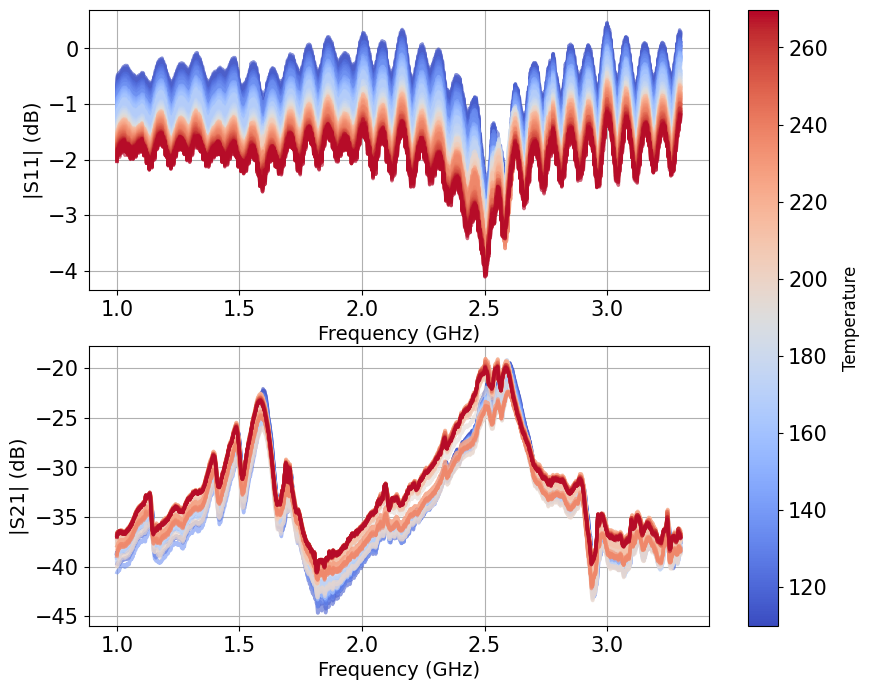

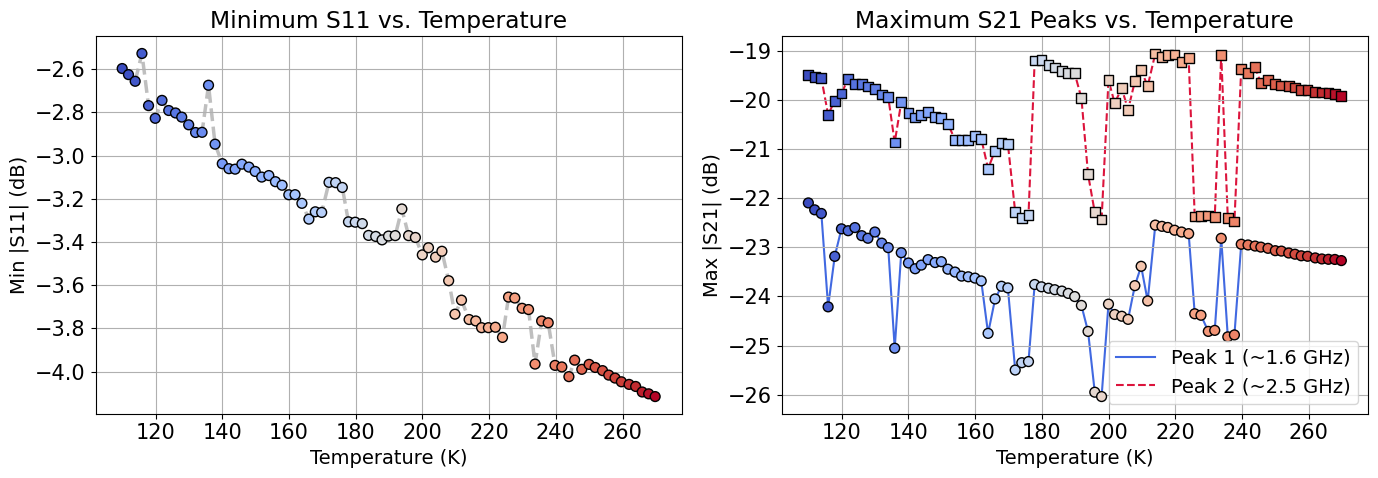

In [32]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize 
from matplotlib.cm import ScalarMappable 

# 1. Get and filter the initial list of files
all_files = list_filenames('/home/electron/data/glass_trap_07132026')

clean_files = []
for file in all_files:
    try:
        temp_val = float(file.replace('.csv', ''))
        # Filter boundary here to avoid loading files we don't want
        if temp_val <= 270:
            clean_files.append(file)
    except ValueError:
        pass

# Sort the files numerically
clean_files.sort(key=lambda x: float(x.replace('.csv', '')))
all_files = clean_files 

# 2. Extract the actual temperature values as floats (now capped at 270)
temperatures = [float(f.replace('.csv', '')) for f in all_files]

# 3. Setup the coolwarm colormap
cmap = plt.colormaps['coolwarm']
norm = Normalize(vmin=min(temperatures), vmax=max(temperatures))

# Setup the ScalarMappable for the colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([]) 

# 4. Initialize lists to collect summary data
temps_list = []
min_s11_list = []
peak1_max_list = []  # To track the ~1.6 GHz peak
peak2_max_list = []  # To track the ~2.5 GHz peak

# ==========================================
# FIGURE 1: Raw Spectra (S11 & S21 vs Freq)
# ==========================================
fig1, ax1 = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

for file in all_files: 
    df = pd.read_csv(f'{folder_path}/data/glass_trap_07132026/{file}') 
    
    S11 = np.abs(np.array(df['S11'], dtype=np.complex128))
    S21 = np.abs(np.array(df['S21'], dtype=np.complex128))
    freq = np.abs(np.array(df['freq'], dtype=np.float64))
    freq_ghz = freq / 1e9

    # Convert to dB
    db_s11 = 20 * np.log10(S11)
    db_s21 = 20 * np.log10(S21)

    # Extract temperature (already guaranteed to be <= 270)
    temp = float(file.replace('.csv', ''))
    current_color = cmap(norm(temp))

    # Plot raw spectra
    ax1[0].plot(freq_ghz, db_s11, color=current_color, alpha=0.6)
    ax1[1].plot(freq_ghz, db_s21, color=current_color, alpha=0.6)
     
    # --- ISOLATE PEAK REGIONS ---
    region1_mask = (freq_ghz >= 1.3) & (freq_ghz <= 1.8)  # Peak 1 (~1.6 GHz)
    region2_mask = (freq_ghz >= 2.2) & (freq_ghz <= 2.8)  # Peak 2 (~2.5 GHz)

    max_peak1 = np.max(db_s21[region1_mask])
    max_peak2 = np.max(db_s21[region2_mask])

    # Collect data for Figure 2
    temps_list.append(temp)
    min_s11_list.append(np.min(db_s11))
    peak1_max_list.append(max_peak1)
    peak2_max_list.append(max_peak2)

# Format Figure 1
ax1[0].set_xlabel('Frequency (GHz)')
ax1[0].set_ylabel('|S11| (dB)')
ax1[0].grid(True)

ax1[1].set_xlabel('Frequency (GHz)')
ax1[1].set_ylabel('|S21| (dB)')
ax1[1].grid(True)

cbar = fig1.colorbar(sm, ax=ax1, orientation='vertical', pad=0.05)
cbar.set_label('Temperature', fontsize=12, labelpad=10)


# ==========================================
# FIGURE 2: Summary Plot (Min/Max vs Temp)
# ==========================================
fig2, ax2 = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Subplot 1: Minimum S11 vs Temperature
ax2[0].plot(temps_list, min_s11_list, color='gray', linestyle='--', alpha=0.5, zorder=1)
ax2[0].scatter(temps_list, min_s11_list, c=temps_list, cmap=cmap, norm=norm, edgecolor='black', s=50, zorder=2)
ax2[0].set_title('Minimum S11 vs. Temperature')
ax2[0].set_xlabel('Temperature (K)')
ax2[0].set_ylabel('Min |S11| (dB)')
ax2[0].grid(True)

# Subplot 2: BOTH S21 Peaks vs Temperature
# Peak 1: Blue line, circular markers (color-coded by temperature)
ax2[1].plot(temps_list, peak1_max_list, color='royalblue', linestyle='-', linewidth=1.5, label='Peak 1 (~1.6 GHz)', zorder=1)
ax2[1].scatter(temps_list, peak1_max_list, c=temps_list, cmap=cmap, norm=norm, marker='o', edgecolor='black', s=50, zorder=2)

# Peak 2: Red line, square markers (color-coded by temperature)
ax2[1].plot(temps_list, peak2_max_list, color='crimson', linestyle='--', linewidth=1.5, label='Peak 2 (~2.5 GHz)', zorder=1)
ax2[1].scatter(temps_list, peak2_max_list, c=temps_list, cmap=cmap, norm=norm, marker='s', edgecolor='black', s=50, zorder=2)

ax2[1].set_title('Maximum S21 Peaks vs. Temperature')
ax2[1].set_xlabel('Temperature (K)')
ax2[1].set_ylabel('Max |S21| (dB)')
ax2[1].grid(True)
ax2[1].legend(loc='best') # Displays which line is which peak

plt.tight_layout()
plt.show()